In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Step 2: Load the dataset from the local CSV file
data = pd.read_csv('BostonHousing.csv') 
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
# Step 3: Explore the dataset
print(data.describe())  # Get a statistical summary of the data

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

In [5]:
print(data.info())  # Check for missing values and data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


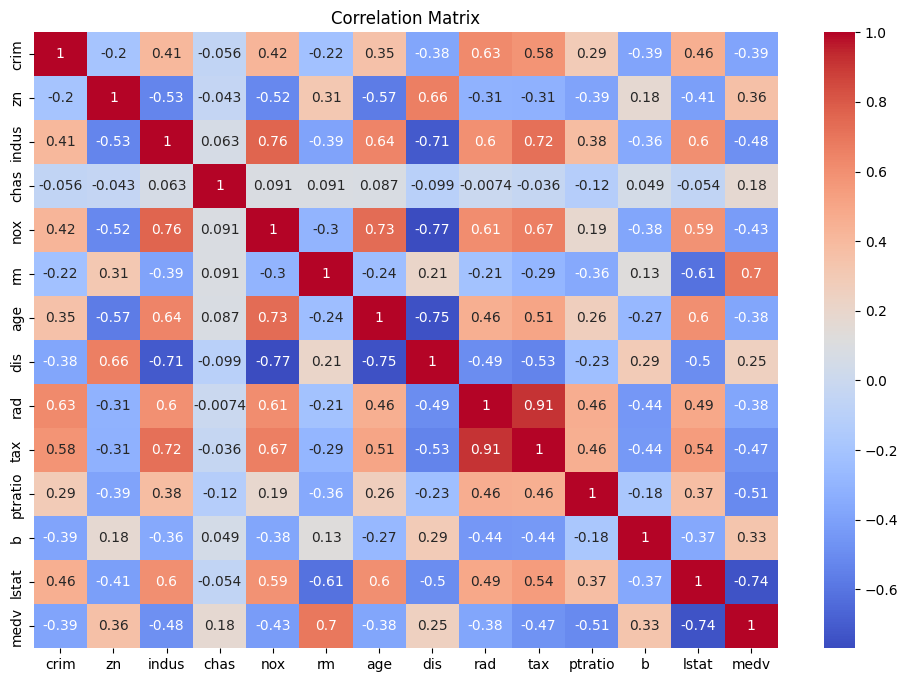

In [6]:
# Step 4: Preprocessing (if necessary)
# In this case, the dataset doesn't have any missing values, so no imputation is needed.
# Check correlation between features to understand relationships with the target variable (Price)
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [24]:
# Step 5: Split the dataset into features and target variable
X = data.drop(columns=['medv'])  # Drop the target column 'medv'
y = data['medv']  # The target variable is 'medv'
# Print Step 5 details
print("Step 5: Features and Target Split")
print("Features (X):", X.columns.tolist())  # Display the features
print("Target (y): 'medv'")

Step 5: Features and Target Split
Features (X): ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
Target (y): 'medv'


In [25]:
# Step 6: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Print Step 6 details
print("\nStep 6: Split the Data into Training and Testing Sets")
print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")


Step 6: Split the Data into Training and Testing Sets
Training data size: (404, 13)
Testing data size: (102, 13)


In [26]:
# Step 7: Create a Linear Regression model
model = LinearRegression()
# Print Step 7 details
print("\nStep 7: Create a Linear Regression Model")
print("Linear Regression model created.")


Step 7: Create a Linear Regression Model
Linear Regression model created.


In [27]:
# Step 8: Train the model
model.fit(X_train, y_train)
# Print Step 8 details
print("\nStep 8: Train the Model")
print("Model trained on the training data.")



Step 8: Train the Model
Model trained on the training data.


In [21]:
# Step 9: Make predictions on the test set
y_pred = model.predict(X_test)


In [22]:
# Step 10: Evaluate the model
# Mean Squared Error (MSE) and R-squared (R²) to evaluate the performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 24.291119474973325
R-squared (R²): 0.6687594935356347


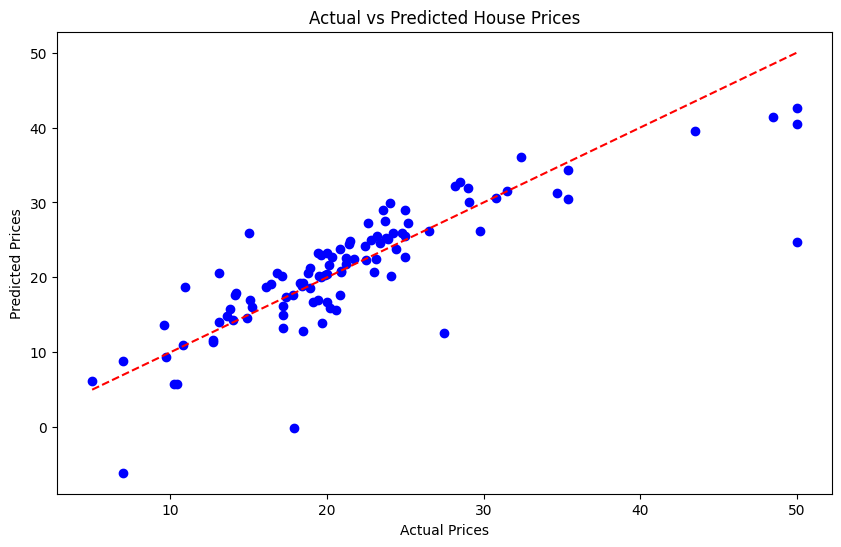

In [23]:
# Step 11: Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()
